# LunarLander DQN 실습

LunarLander 환경에서 Deep Q-Network (DQN)를 사용하여 달 착륙을 학습합니다.

환경 설정

In [3]:
# 필요한 라이브러리 설치
!apt-get install -y swig -qq
!pip install gymnasium[box2d] -q
!pip install pygame -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
from matplotlib import animation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('default')
sns.set_palette("husl")

# PyTorch 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Selecting previously unselected package swig4.0.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu1_all.deb ...
Unpacking swig (4.0.2-1ubuntu1) ...
Setting up swig4.0 (4.0.2-1ubuntu1) ...
Setting up swig (4.0.2-1ubuntu1) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
Using device: cpu


## 1. LunarLander 환경 이해하기

In [4]:
# 환경 생성
env = gym.make('LunarLander-v3')

print("=" * 60)
print("LunarLander-v3 환경 정보")
print("=" * 60)
print(f"State 공간: {env.observation_space}")
print(f"Action 공간: {env.action_space}")
print(f"\nState 구성 요소 (8차원):")
print("  - X 좌표: 착륙선의 수평 위치")
print("  - Y 좌표: 착륙선의 수직 위치")
print("  - X 속도: 수평 속도")
print("  - Y 속도: 수직 속도")
print("  - 각도: 착륙선의 기울어진 각도")
print("  - 각속도: 회전 속도")
print("  - 왼쪽 다리 접촉: 지면에 닿았는지 (0 or 1)")
print("  - 오른쪽 다리 접촉: 지면에 닿았는지 (0 or 1)")
print(f"\nAction (4가지):")
print("  - 0: 아무것도 하지 않기")
print("  - 1: 왼쪽 엔진 분사")
print("  - 2: 메인 엔진 분사 (아래로)")
print("  - 3: 오른쪽 엔진 분사")
print(f"\n보상 체계:")
print("  - 착륙 성공: +100 ~ +140")
print("  - 추락 또는 범위 이탈: -100")
print("  - 다리가 지면에 닿음: +10")
print("  - 엔진 사용: -0.3 (연료 소비)")
print(f"\n목표: 안전하게 착륙하기 (평균 200점 이상)")


LunarLander-v3 환경 정보
State 공간: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action 공간: Discrete(4)

State 구성 요소 (8차원):
  - X 좌표: 착륙선의 수평 위치
  - Y 좌표: 착륙선의 수직 위치
  - X 속도: 수평 속도
  - Y 속도: 수직 속도
  - 각도: 착륙선의 기울어진 각도
  - 각속도: 회전 속도
  - 왼쪽 다리 접촉: 지면에 닿았는지 (0 or 1)
  - 오른쪽 다리 접촉: 지면에 닿았는지 (0 or 1)

Action (4가지):
  - 0: 아무것도 하지 않기
  - 1: 왼쪽 엔진 분사
  - 2: 메인 엔진 분사 (아래로)
  - 3: 오른쪽 엔진 분사

보상 체계:
  - 착륙 성공: +100 ~ +140
  - 추락 또는 범위 이탈: -100
  - 다리가 지면에 닿음: +10
  - 엔진 사용: -0.3 (연료 소비)

목표: 안전하게 착륙하기 (평균 200점 이상)


## 2. Replay Buffer 구현

DQN의 핵심 요소: 경험을 저장하고 랜덤하게 샘플링하여 학습

In [5]:
class ReplayBuffer:
    """경험 재생 버퍼"""

    def __init__(self, capacity=100000):
        """
        Args:
            capacity: 버퍼의 최대 크기
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """경험을 버퍼에 저장"""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """랜덤하게 배치 샘플링"""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.uint8)
        )

    def __len__(self):
        return len(self.buffer)

print("\n" + "=" * 60)
print("Replay Buffer 생성 완료")
print("=" * 60)
print("용량: 100,000개 경험")


Replay Buffer 생성 완료
용량: 100,000개 경험


## 3. DQN Network 구현

Deep Q-Network: state를 입력받아 각 action의 Q값을 출력하는 신경망

In [6]:
class DQN(nn.Module):
    """Deep Q-Network"""

    def __init__(self, state_dim, action_dim, hidden_dim=128):
        """
        Args:
            state_dim: state 차원
            action_dim: action 개수
            hidden_dim: 은닉층 뉴런 수
        """
        super(DQN, self).__init__()

        # Fully Connected Layers
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        """순전파"""
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 네트워크 생성
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Q-Network와 Target Network 생성
q_network = DQN(state_dim, action_dim).to(device)
target_network = DQN(state_dim, action_dim).to(device)

# Target Network를 Q-Network와 동일하게 초기화
target_network.load_state_dict(q_network.state_dict())
target_network.eval()  # Target network는 평가 모드

print("\n" + "=" * 60)
print("DQN Network 구조")
print("=" * 60)
print(q_network)

total_params = sum(p.numel() for p in q_network.parameters())
print(f"\n총 파라미터 수: {total_params:,}")


DQN Network 구조
DQN(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

총 파라미터 수: 18,180


## 4. DQN Agent 구현

In [7]:
class DQNAgent:
    """DQN 에이전트"""

    def __init__(self, q_network, target_network, state_dim, action_dim,
                 learning_rate=0.001, gamma=0.99, epsilon=1.0,
                 epsilon_decay=0.995, epsilon_min=0.01,
                 target_update_freq=10):
        """
        Args:
            q_network: Q-Network
            target_network: Target Network
            state_dim: state 차원
            action_dim: action 개수
            learning_rate: 학습률
            gamma: 할인율
            epsilon: 초기 탐험률
            epsilon_decay: epsilon 감소율
            epsilon_min: 최소 epsilon
            target_update_freq: Target Network 업데이트 빈도 (에피소드)
        """
        self.q_network = q_network
        self.target_network = target_network
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.target_update_freq = target_update_freq

        # Optimizer 및 Loss
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

        # Replay Buffer
        self.replay_buffer = ReplayBuffer(capacity=100000)

        # 통계
        self.episode_count = 0

    def get_action(self, state, training=True):
        """Epsilon-greedy 정책으로 action 선택"""
        if training and random.random() < self.epsilon:
            # 탐험: 랜덤 action
            return random.randint(0, self.action_dim - 1)
        else:
            # 활용: Q값이 최대인 action
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.q_network(state_tensor)
                return q_values.argmax().item()

    def update(self, batch_size=64):
        """Replay Buffer에서 샘플링하여 네트워크 업데이트"""
        if len(self.replay_buffer) < batch_size:
            return None

        # 배치 샘플링
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        # Numpy array를 Tensor로 변환
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)

        # 현재 Q값 계산
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q값 계산 (Double DQN 방식)
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values

        # Loss 계산 및 역전파
        loss = self.loss_fn(current_q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping (학습 안정화)
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 10)
        self.optimizer.step()

        return loss.item()

    def decay_epsilon(self):
        """Epsilon 감소"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_target_network(self):
        """Target Network를 Q-Network로 업데이트"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def episode_done(self):
        """에피소드 종료 시 호출"""
        self.episode_count += 1

        # Target Network 주기적 업데이트
        if self.episode_count % self.target_update_freq == 0:
            self.update_target_network()

# Agent 생성
agent = DQNAgent(
    q_network=q_network,
    target_network=target_network,
    state_dim=state_dim,
    action_dim=action_dim,
    learning_rate=0.001,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    target_update_freq=10
)

print("\n" + "=" * 60)
print("DQN Agent 생성 완료")
print("=" * 60)


DQN Agent 생성 완료


## 5. 학습 진행

In [8]:
def train_dqn_agent(agent, env, num_episodes=1000, batch_size=64,
                    warmup_episodes=50, max_steps=1000):
    """DQN 에이전트 학습"""

    episode_rewards = []
    episode_lengths = []
    epsilon_history = []
    loss_history = []
    recent_rewards = deque(maxlen=100)

    print("\n" + "=" * 60)
    print("학습 시작")
    print("=" * 60)
    print(f"Warmup 에피소드: {warmup_episodes} (랜덤 탐험으로 버퍼 채우기)")
    print(f"학습 에피소드: {num_episodes}")
    print(f"배치 크기: {batch_size}\n")

    for episode in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        episode_loss = []

        for step in range(max_steps):
            # Action 선택
            action = agent.get_action(state, training=True)

            # 환경에서 한 스텝 진행
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Replay Buffer에 저장
            agent.replay_buffer.push(state, action, reward, next_state, done)

            # Warmup 이후 학습 시작
            if episode >= warmup_episodes:
                loss = agent.update(batch_size)
                if loss is not None:
                    episode_loss.append(loss)

            total_reward += reward
            state = next_state

            if done:
                break

        # Epsilon 감소
        agent.decay_epsilon()

        # 에피소드 종료 처리
        agent.episode_done()

        # 통계 기록
        episode_rewards.append(total_reward)
        episode_lengths.append(step + 1)
        epsilon_history.append(agent.epsilon)
        recent_rewards.append(total_reward)

        avg_loss = np.mean(episode_loss) if episode_loss else 0
        loss_history.append(avg_loss)

        # 진행상황 출력
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(recent_rewards)
            print(f"Episode {episode + 1}/{num_episodes} | "
                  f"Avg Reward (last 100): {avg_reward:.2f} | "
                  f"Epsilon: {agent.epsilon:.4f} | "
                  f"Buffer Size: {len(agent.replay_buffer):,} | "
                  f"Avg Loss: {avg_loss:.4f}")

    print("\n학습 완료!")

    return episode_rewards, episode_lengths, epsilon_history, loss_history

# 학습 실행
num_episodes = 1000
episode_rewards, episode_lengths, epsilon_history, loss_history = train_dqn_agent(
    agent, env, num_episodes=num_episodes, batch_size=64, warmup_episodes=50
)


학습 시작
Warmup 에피소드: 50 (랜덤 탐험으로 버퍼 채우기)
학습 에피소드: 1000
배치 크기: 64

Episode 50/1000 | Avg Reward (last 100): -177.10 | Epsilon: 0.7783 | Buffer Size: 4,573 | Avg Loss: 0.0000
Episode 100/1000 | Avg Reward (last 100): -149.03 | Epsilon: 0.6058 | Buffer Size: 11,156 | Avg Loss: 27.1775
Episode 150/1000 | Avg Reward (last 100): -87.33 | Epsilon: 0.4715 | Buffer Size: 21,772 | Avg Loss: 19.7736
Episode 200/1000 | Avg Reward (last 100): -49.53 | Epsilon: 0.3670 | Buffer Size: 47,854 | Avg Loss: 18.4918
Episode 250/1000 | Avg Reward (last 100): -34.73 | Epsilon: 0.2856 | Buffer Size: 86,857 | Avg Loss: 22.3315
Episode 300/1000 | Avg Reward (last 100): -19.59 | Epsilon: 0.2223 | Buffer Size: 100,000 | Avg Loss: 10.1856
Episode 350/1000 | Avg Reward (last 100): 14.41 | Epsilon: 0.1730 | Buffer Size: 100,000 | Avg Loss: 4.7359
Episode 400/1000 | Avg Reward (last 100): 78.10 | Epsilon: 0.1347 | Buffer Size: 100,000 | Avg Loss: 6.5098
Episode 450/1000 | Avg Reward (last 100): 110.21 | Epsilon: 0.104

## 6. 학습 결과 시각화

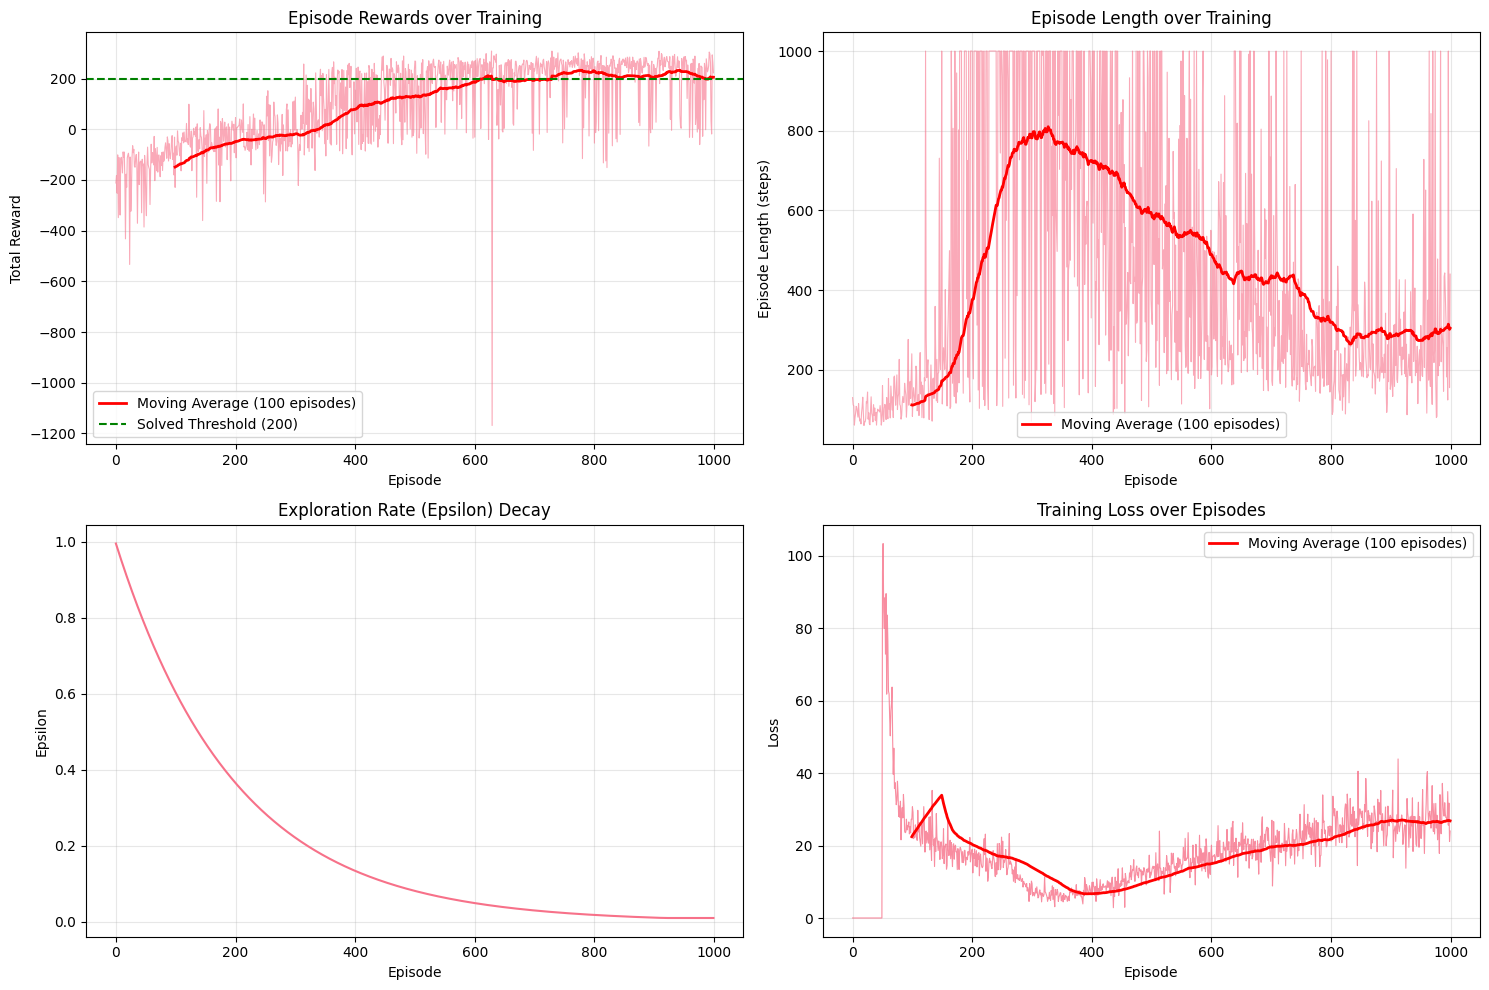


학습 통계
총 에피소드 수: 1000
최고 보상: 308.43
최근 100 에피소드 평균 보상: 205.27
최종 Epsilon: 0.0100
Replay Buffer 크기: 100,000

🎉 환경 해결! (Solved: 200+ average reward)


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Episode Rewards
axes[0, 0].plot(episode_rewards, alpha=0.6, linewidth=0.8)
moving_avg = np.convolve(episode_rewards, np.ones(100)/100, mode='valid')
axes[0, 0].plot(range(99, len(episode_rewards)), moving_avg, 'r-', linewidth=2,
                label='Moving Average (100 episodes)')
axes[0, 0].axhline(y=200, color='g', linestyle='--', label='Solved Threshold (200)')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Episode Rewards over Training')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Episode Lengths
axes[0, 1].plot(episode_lengths, alpha=0.6, linewidth=0.8)
moving_avg_len = np.convolve(episode_lengths, np.ones(100)/100, mode='valid')
axes[0, 1].plot(range(99, len(episode_lengths)), moving_avg_len, 'r-', linewidth=2,
                label='Moving Average (100 episodes)')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Episode Length (steps)')
axes[0, 1].set_title('Episode Length over Training')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Epsilon Decay
axes[1, 0].plot(epsilon_history)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Epsilon')
axes[1, 0].set_title('Exploration Rate (Epsilon) Decay')
axes[1, 0].grid(True, alpha=0.3)

# Training Loss
axes[1, 1].plot(loss_history, alpha=0.8, linewidth=0.8)
if len(loss_history) > 100:
    moving_avg_loss = np.convolve(loss_history, np.ones(100)/100, mode='valid')
    axes[1, 1].plot(range(99, len(loss_history)), moving_avg_loss, 'r-', linewidth=2,
                    label='Moving Average (100 episodes)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Training Loss over Episodes')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 학습 통계
print("\n" + "=" * 60)
print("학습 통계")
print("=" * 60)
print(f"총 에피소드 수: {num_episodes}")
print(f"최고 보상: {max(episode_rewards):.2f}")
print(f"최근 100 에피소드 평균 보상: {np.mean(episode_rewards[-100:]):.2f}")
print(f"최종 Epsilon: {agent.epsilon:.4f}")
print(f"Replay Buffer 크기: {len(agent.replay_buffer):,}")

# LunarLander-v2는 평균 200점 이상이면 "solved"로 간주
if np.mean(episode_rewards[-100:]) >= 200:
    print("\n🎉 환경 해결! (Solved: 200+ average reward)")
else:
    print("\n계속 학습하면 더 좋은 성능을 얻을 수 있습니다!")

## 7. 학습된 에이전트 테스트

In [11]:
def test_dqn_agent(agent, env, num_episodes=10):
    """학습된 DQN 에이전트 테스트"""

    test_rewards = []
    test_lengths = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        steps = 0

        while True:
            # 학습된 정책으로 action 선택 (탐험 없음)
            action = agent.get_action(state, training=False)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        test_rewards.append(total_reward)
        test_lengths.append(steps)

        # 성공/실패 판정
        status = "✓ Success" if total_reward >= 200 else "✗ Failed"
        print(f"Test Episode {episode + 1}: Reward = {total_reward:.2f}, Length = {steps} {status}")

    return test_rewards, test_lengths

print("\n" + "=" * 60)
print("학습된 에이전트 테스트")
print("=" * 60)

test_rewards, test_lengths = test_dqn_agent(agent, env, num_episodes=10)

print("\n" + "=" * 60)
print("테스트 결과")
print("=" * 60)
print(f"평균 보상: {np.mean(test_rewards):.2f} ± {np.std(test_rewards):.2f}")
print(f"평균 길이: {np.mean(test_lengths):.2f} ± {np.std(test_lengths):.2f}")
print(f"최고 보상: {max(test_rewards):.2f}")
print(f"최저 보상: {min(test_rewards):.2f}")
print(f"성공률: {sum(1 for r in test_rewards if r >= 200)}/10")


학습된 에이전트 테스트
Test Episode 1: Reward = -8.88, Length = 104 ✗ Failed
Test Episode 2: Reward = 268.31, Length = 189 ✓ Success
Test Episode 3: Reward = 253.98, Length = 181 ✓ Success
Test Episode 4: Reward = 292.96, Length = 261 ✓ Success
Test Episode 5: Reward = 149.84, Length = 1000 ✗ Failed
Test Episode 6: Reward = 294.51, Length = 248 ✓ Success
Test Episode 7: Reward = 180.62, Length = 637 ✗ Failed
Test Episode 8: Reward = 261.46, Length = 162 ✓ Success
Test Episode 9: Reward = 255.79, Length = 194 ✓ Success
Test Episode 10: Reward = 248.24, Length = 194 ✓ Success

테스트 결과
평균 보상: 219.68 ± 87.76
평균 길이: 317.00 ± 266.71
최고 보상: 294.51
최저 보상: -8.88
성공률: 7/10


## 8. 실제 플레이 시각화

In [12]:
def visualize_best_episode(agent, env, num_trials=10):
    """여러 번 실행해서 가장 좋은 에피소드를 시각화"""

    print(f"\n{'='*60}")
    print(f"최고 성능 에피소드 찾는 중... ({num_trials}번 시도)")
    print(f"{'='*60}\n")

    best_frames = None
    best_reward = -1000
    best_steps = 0

    # 여러 번 실행해서 가장 좋은 것 찾기
    for trial in range(num_trials):
        env_render = gym.make('LunarLander-v3', render_mode='rgb_array')
        state, _ = env_render.reset()

        frames = []
        total_reward = 0
        step = 0

        while True:
            frame = env_render.render()
            frames.append(frame)

            action = agent.get_action(state, training=False)
            next_state, reward, terminated, truncated, _ = env_render.step(action)
            done = terminated or truncated

            total_reward += reward
            step += 1
            state = next_state

            if done:
                break

        env_render.close()

        status = "✓" if total_reward >= 200 else "✗"
        print(f"Trial {trial + 1}/{num_trials}: Reward = {total_reward:.2f}, Steps = {step} {status}")

        # 최고 기록 갱신
        if total_reward > best_reward:
            best_reward = total_reward
            best_steps = step
            best_frames = frames.copy()
            # 마지막 프레임 반복
            for _ in range(20):
                best_frames.append(frames[-1])

    print(f"\n{'='*60}")
    print(f"최고 성능 에피소드 선택!")
    print(f"Best Reward: {best_reward:.2f}, Best Steps: {best_steps}")
    print(f"{'='*60}\n")

    # 최고 에피소드 애니메이션 생성 및 표시
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis('off')
    img = ax.imshow(best_frames[0])

    def animate(frame_idx):
        img.set_array(best_frames[frame_idx])
        if frame_idx < best_steps:
            ax.set_title(f'Step: {frame_idx + 1}/{best_steps} | Best Episode (Reward: {best_reward:.1f})',
                        fontsize=14, fontweight='bold')
        else:
            status_text = "SUCCESS!" if best_reward >= 200 else "Finished"
            color = 'green' if best_reward >= 200 else 'blue'
            ax.set_title(f'{status_text} | Total Steps: {best_steps} | Total Reward: {best_reward:.1f}',
                        fontsize=14, fontweight='bold', color=color)
        return [img]

    anim = animation.FuncAnimation(fig, animate, frames=len(best_frames),
                                  interval=50, blit=True, repeat=True)

    plt.close()
    return HTML(anim.to_jshtml())

# 학습된 에이전트의 최고 플레이 시각화
print("\n" + "=" * 60)
print("학습된 에이전트 최고 플레이 시각화")
print("=" * 60)

visualize_best_episode(agent, env, num_trials=10)


학습된 에이전트 최고 플레이 시각화

최고 성능 에피소드 찾는 중... (10번 시도)

Trial 1/10: Reward = 276.59, Steps = 231 ✓
Trial 2/10: Reward = 296.12, Steps = 243 ✓
Trial 3/10: Reward = 261.49, Steps = 162 ✓
Trial 4/10: Reward = 311.12, Steps = 223 ✓
Trial 5/10: Reward = 279.81, Steps = 296 ✓
Trial 6/10: Reward = 272.69, Steps = 647 ✓
Trial 7/10: Reward = 244.42, Steps = 317 ✓
Trial 8/10: Reward = 261.64, Steps = 204 ✓
Trial 9/10: Reward = 255.03, Steps = 166 ✓
Trial 10/10: Reward = 255.54, Steps = 179 ✓

최고 성능 에피소드 선택!
Best Reward: 311.12, Best Steps: 223



## 9. Q-Network 분석


Q-Network 분석


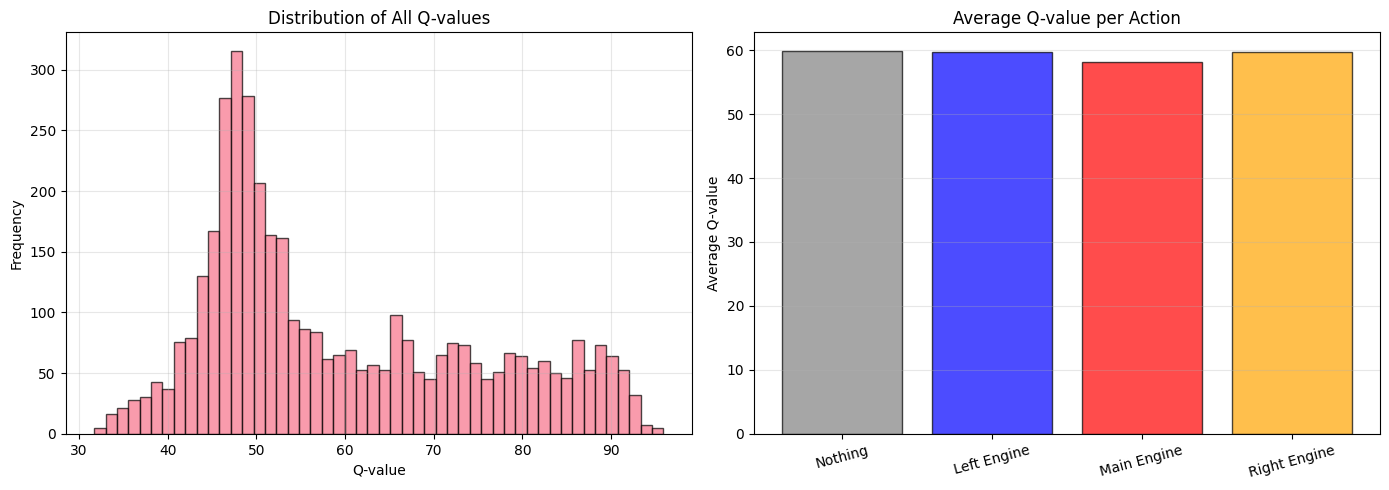


Q-값 통계:
평균 Q-값: 59.3646
최대 Q-값: 95.8997
최소 Q-값: 31.6878

Action별 평균 Q-값:
  Nothing: 59.7936
  Left Engine: 59.7445
  Main Engine: 58.1890
  Right Engine: 59.7312


In [13]:
# 9.1 랜덤 state에 대한 Q-값 분포
print("\n" + "=" * 60)
print("Q-Network 분석")
print("=" * 60)

# 테스트 데이터에서 Q-값 수집
num_samples = 1000
q_values_distribution = []

for _ in range(num_samples):
    state, _ = env.reset()
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

    with torch.no_grad():
        q_values = agent.q_network(state_tensor).cpu().numpy()[0]
        q_values_distribution.append(q_values)

q_values_distribution = np.array(q_values_distribution)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 모든 Q-값 분포
axes[0].hist(q_values_distribution.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Q-value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of All Q-values')
axes[0].grid(True, alpha=0.3)

# Action별 평균 Q-값
action_names = ['Nothing', 'Left Engine', 'Main Engine', 'Right Engine']
avg_q_per_action = q_values_distribution.mean(axis=0)
colors = ['gray', 'blue', 'red', 'orange']

axes[1].bar(action_names, avg_q_per_action, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Average Q-value')
axes[1].set_title('Average Q-value per Action')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(f"\nQ-값 통계:")
print(f"평균 Q-값: {q_values_distribution.mean():.4f}")
print(f"최대 Q-값: {q_values_distribution.max():.4f}")
print(f"최소 Q-값: {q_values_distribution.min():.4f}")
print(f"\nAction별 평균 Q-값:")
for action_name, avg_q in zip(action_names, avg_q_per_action):
    print(f"  {action_name}: {avg_q:.4f}")

# 환경 종료
env.close()